In [2]:
import pandas as pd
import os
from tqdm import tqdm

# Path to your training folder
path_A = "training/training/training_setA"
path_B = "training/training/training_setB"

def load_training_data(folder_path):
    all_patients = []
    for file in tqdm(os.listdir(folder_path)):
        if file.endswith(".psv"):
            patient_id = file.replace(".psv", "")
            df = pd.read_csv(os.path.join(folder_path, file), sep='|')
            df["Patient_ID"] = patient_id
            all_patients.append(df)
    return pd.concat(all_patients, ignore_index=True)

# Load both sets
dfA = load_training_data(path_A)
dfB = load_training_data(path_B)

# Combine A + B
data = pd.concat([dfA, dfB], ignore_index=True)
print("Shape:", data.shape)
print(data.head())


100%|██████████| 20000/20000 [06:47<00:00, 49.11it/s]


Shape: (1552210, 42)
      HR  O2Sat  Temp    SBP    MAP  DBP  Resp  EtCO2  BaseExcess  HCO3  ...  \
0    NaN    NaN   NaN    NaN    NaN  NaN   NaN    NaN         NaN   NaN  ...   
1   97.0   95.0   NaN   98.0  75.33  NaN  19.0    NaN         NaN   NaN  ...   
2   89.0   99.0   NaN  122.0  86.00  NaN  22.0    NaN         NaN   NaN  ...   
3   90.0   95.0   NaN    NaN    NaN  NaN  30.0    NaN        24.0   NaN  ...   
4  103.0   88.5   NaN  122.0  91.33  NaN  24.5    NaN         NaN   NaN  ...   

   Fibrinogen  Platelets    Age  Gender  Unit1  Unit2  HospAdmTime  ICULOS  \
0         NaN        NaN  83.14       0    NaN    NaN        -0.03       1   
1         NaN        NaN  83.14       0    NaN    NaN        -0.03       2   
2         NaN        NaN  83.14       0    NaN    NaN        -0.03       3   
3         NaN        NaN  83.14       0    NaN    NaN        -0.03       4   
4         NaN        NaN  83.14       0    NaN    NaN        -0.03       5   

   SepsisLabel  Patient_ID  


In [3]:
data.isna().mean().sort_values(ascending=False).head(20)
data

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,80.0,96.0,NaN,115.0,87.00,65.0,15.0,NaN,NaN,NaN,...,NaN,NaN,62.00,0,NaN,NaN,0.00,31,0,p120000
1552206,74.0,97.0,NaN,114.0,83.00,67.0,15.0,NaN,NaN,NaN,...,NaN,NaN,62.00,0,NaN,NaN,0.00,32,0,p120000
1552207,78.0,98.0,NaN,110.0,83.00,69.0,15.0,NaN,NaN,NaN,...,NaN,NaN,62.00,0,NaN,NaN,0.00,33,0,p120000
1552208,82.0,99.0,36.6,124.0,91.00,71.0,16.0,NaN,NaN,NaN,...,NaN,NaN,62.00,0,NaN,NaN,0.00,34,0,p120000


In [4]:
data['SepsisLabel'].value_counts(normalize=True)
data

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,80.0,96.0,NaN,115.0,87.00,65.0,15.0,NaN,NaN,NaN,...,NaN,NaN,62.00,0,NaN,NaN,0.00,31,0,p120000
1552206,74.0,97.0,NaN,114.0,83.00,67.0,15.0,NaN,NaN,NaN,...,NaN,NaN,62.00,0,NaN,NaN,0.00,32,0,p120000
1552207,78.0,98.0,NaN,110.0,83.00,69.0,15.0,NaN,NaN,NaN,...,NaN,NaN,62.00,0,NaN,NaN,0.00,33,0,p120000
1552208,82.0,99.0,36.6,124.0,91.00,71.0,16.0,NaN,NaN,NaN,...,NaN,NaN,62.00,0,NaN,NaN,0.00,34,0,p120000


In [8]:
# Step 1️⃣: Drop columns with >90% missing values
missing_ratio = data.isna().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.9].index
print(f"Dropping {len(cols_to_drop)} columns with >90% missing values...")
data = data.drop(columns=cols_to_drop)

# 🧩 Fix index issues before grouping
data = data.reset_index(drop=True)
if 'Patient_ID' in data.index.names:
    data = data.reset_index()

# Step 2️⃣: Fill missing values (forward/backward per patient)
data = (
    data.groupby('Patient_ID', group_keys=False)
        .apply(lambda x: x.ffill().bfill())
        .reset_index(drop=True)
)

# Step 3️⃣: Fill remaining numeric NaNs with median
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# Step 4️⃣: Fill remaining non-numeric NaNs with mode (if any)
non_num_cols = data.select_dtypes(exclude=['float64', 'int64']).columns
for col in non_num_cols:
    if data[col].isna().any():
        data[col] = data[col].fillna(data[col].mode()[0] if not data[col].mode().empty else 0)

# Step 5️⃣: Encode Gender if present
if 'Gender' in data.columns:
    data['Gender'] = data['Gender'].map({0:0, 1:1})


Dropping 0 columns with >90% missing values...


C:\Users\saisr\AppData\Local\Temp\ipykernel_23720\3048395172.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.ffill().bfill())


In [9]:
print("\n✅ Data after cleaning and filling:")
print(f"Shape: {data.shape}")
print("\nColumn list:")
print(data.columns.tolist())

# Show top rows
display(data.head(10))

# Quick missing-value summary
print("\nMissing value ratio (Top 15):")
print(data.isna().mean().sort_values(ascending=False).head(15))

# Check how many unique patients and label distribution
if 'SepsisLabel' in data.columns:
    print("\nUnique Patients:", data['Patient_ID'].nunique())
    print("\nSepsisLabel distribution:")
    print(data['SepsisLabel'].value_counts(normalize=True))



✅ Data after cleaning and filling:
Shape: (1552210, 15)

Column list:
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,97.0,95.0,36.11,98.0,75.33,62.0,19.0,83.14,0,0.0,1.0,-0.03,1,0,p000001
1,97.0,95.0,36.11,98.0,75.33,62.0,19.0,83.14,0,0.0,1.0,-0.03,2,0,p000001
2,89.0,99.0,36.11,122.0,86.00,62.0,22.0,83.14,0,0.0,1.0,-0.03,3,0,p000001
3,90.0,95.0,36.11,122.0,86.00,62.0,30.0,83.14,0,0.0,1.0,-0.03,4,0,p000001
4,103.0,88.5,36.11,122.0,91.33,62.0,24.5,83.14,0,0.0,1.0,-0.03,5,0,p000001
5,110.0,91.0,36.11,122.0,91.33,62.0,22.0,83.14,0,0.0,1.0,-0.03,6,0,p000001
6,108.0,92.0,36.11,123.0,77.00,62.0,29.0,83.14,0,0.0,1.0,-0.03,7,0,p000001
7,106.0,90.5,36.11,93.0,76.33,62.0,29.0,83.14,0,0.0,1.0,-0.03,8,0,p000001
8,104.0,95.0,36.11,133.0,88.33,62.0,26.0,83.14,0,0.0,1.0,-0.03,9,0,p000001
9,102.0,91.0,36.11,134.0,87.33,62.0,30.0,83.14,0,0.0,1.0,-0.03,10,0,p000001



Missing value ratio (Top 15):
HR             0.0
O2Sat          0.0
Temp           0.0
SBP            0.0
MAP            0.0
DBP            0.0
Resp           0.0
Age            0.0
Gender         0.0
Unit1          0.0
Unit2          0.0
HospAdmTime    0.0
ICULOS         0.0
SepsisLabel    0.0
Patient_ID     0.0
dtype: float64

Unique Patients: 40336

SepsisLabel distribution:
SepsisLabel
0    0.982015
1    0.017985
Name: proportion, dtype: float64



✅ Data after cleaning and filling:
Shape: (1552210, 15)

Columns remaining:
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,97.0,95.0,36.11,98.0,75.33,62.0,19.0,83.14,0,0.0,1.0,-0.03,1,0,p000001
1,97.0,95.0,36.11,98.0,75.33,62.0,19.0,83.14,0,0.0,1.0,-0.03,2,0,p000001
2,89.0,99.0,36.11,122.0,86.00,62.0,22.0,83.14,0,0.0,1.0,-0.03,3,0,p000001
3,90.0,95.0,36.11,122.0,86.00,62.0,30.0,83.14,0,0.0,1.0,-0.03,4,0,p000001
4,103.0,88.5,36.11,122.0,91.33,62.0,24.5,83.14,0,0.0,1.0,-0.03,5,0,p000001
5,110.0,91.0,36.11,122.0,91.33,62.0,22.0,83.14,0,0.0,1.0,-0.03,6,0,p000001
6,108.0,92.0,36.11,123.0,77.00,62.0,29.0,83.14,0,0.0,1.0,-0.03,7,0,p000001
7,106.0,90.5,36.11,93.0,76.33,62.0,29.0,83.14,0,0.0,1.0,-0.03,8,0,p000001
8,104.0,95.0,36.11,133.0,88.33,62.0,26.0,83.14,0,0.0,1.0,-0.03,9,0,p000001
9,102.0,91.0,36.11,134.0,87.33,62.0,30.0,83.14,0,0.0,1.0,-0.03,10,0,p000001



Missing value ratio (Top 15):
HR             0.0
O2Sat          0.0
Temp           0.0
SBP            0.0
MAP            0.0
DBP            0.0
Resp           0.0
Age            0.0
Gender         0.0
Unit1          0.0
Unit2          0.0
HospAdmTime    0.0
ICULOS         0.0
SepsisLabel    0.0
Patient_ID     0.0
dtype: float64

Unique Patients: 40336
SepsisLabel distribution:
SepsisLabel
0    0.982015
1    0.017985
Name: proportion, dtype: float64


C:\Users\saisr\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


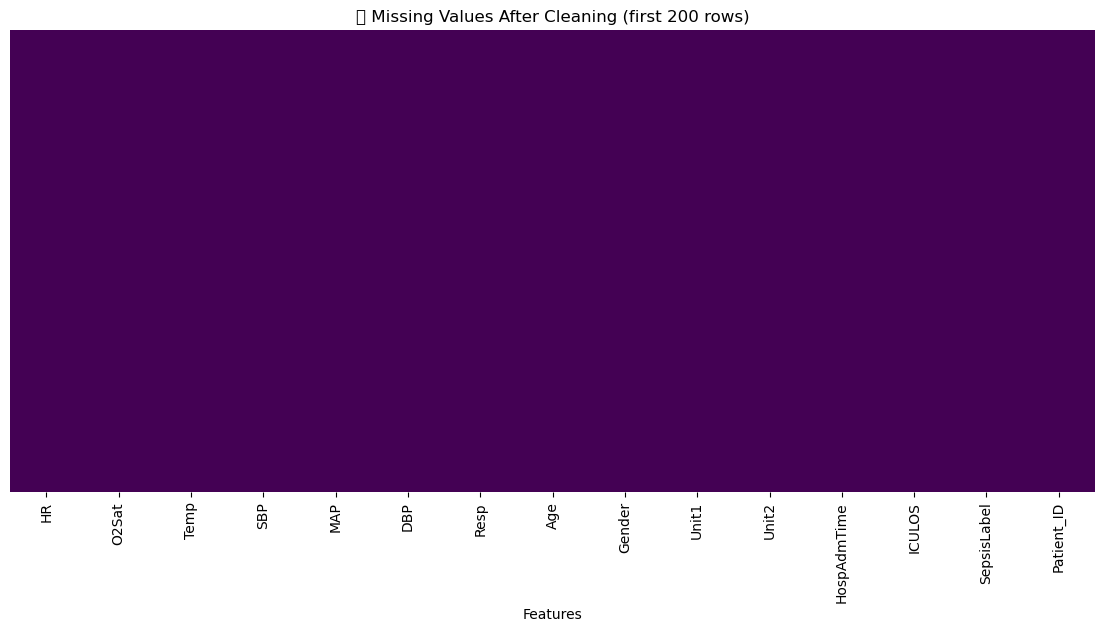

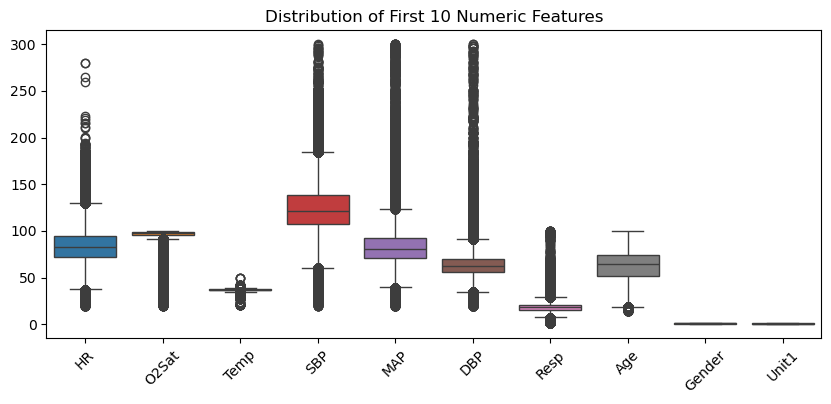

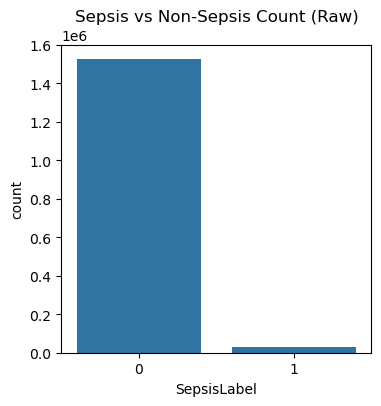

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n✅ Data after cleaning and filling:")
print(f"Shape: {data.shape}")
print("\nColumns remaining:")
print(data.columns.tolist())

# Show first few rows
display(data.head(10))

# --- Missing-value summary ---
print("\nMissing value ratio (Top 15):")
missing_ratio = data.isna().mean().sort_values(ascending=False)
print(missing_ratio.head(15))

# --- Basic dataset info ---
if 'SepsisLabel' in data.columns:
    print("\nUnique Patients:", data['Patient_ID'].nunique())
    print("SepsisLabel distribution:")
    print(data['SepsisLabel'].value_counts(normalize=True))

# --- Missing-value heatmap (first 200 rows for readability) ---
plt.figure(figsize=(14,6))
sns.heatmap(data.head(200).isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("🩺 Missing Values After Cleaning (first 200 rows)")
plt.xlabel("Features")
plt.show()

# --- Quick look at numerical distributions ---
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(10,4))
sns.boxplot(data=data[numeric_cols].iloc[:, :10])  # first 10 numeric cols
plt.title("Distribution of First 10 Numeric Features")
plt.xticks(rotation=45)
plt.show()

# --- Sepsis vs Non-Sepsis counts ---
if 'SepsisLabel' in data.columns:
    plt.figure(figsize=(4,4))
    sns.countplot(x='SepsisLabel', data=data)
    plt.title("Sepsis vs Non-Sepsis Count (Raw)")
    plt.show()


In [11]:
import numpy as np

# Select numeric columns only
num_cols = data.select_dtypes(include=['float64', 'int64']).columns

outlier_summary = {}

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((data[col] < lower) | (data[col] > upper)).sum()
    outlier_summary[col] = round((outliers / len(data)) * 100, 2)

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['% Outliers'])
outlier_df = outlier_df.sort_values(by='% Outliers', ascending=False)

print("🔍 Percentage of outliers per feature (Top 15):")
display(outlier_df.head(15))


🔍 Percentage of outliers per feature (Top 15):


,% Outliers
HospAdmTime,13.73
ICULOS,4.60
Resp,4.01
DBP,3.62
O2Sat,2.90
SepsisLabel,1.80
Temp,1.70
MAP,1.67
SBP,1.22
HR,1.16


In [12]:
import numpy as np

for col in ['HospAdmTime', 'Resp', 'DBP', 'O2Sat', 'Temp', 'MAP', 'SBP', 'HR']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = np.clip(data[col], lower, upper)

print("Mild clipping applied to main vital features to limit extreme outliers.")


Mild clipping applied to main vital features to limit extreme outliers.


In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
from sklearn.utils import resample
import pandas as pd
import numpy as np

# --- Group by patient to extract one record per patient for sampling ---
patient_summary = (
    data.groupby('Patient_ID')
    .agg({col: 'mean' for col in data.columns if col not in ['Patient_ID', 'SepsisLabel']})
    .join(data.groupby('Patient_ID')['SepsisLabel'].max())
    .reset_index()
)

print(f"Total patients: {len(patient_summary)}")
print(patient_summary['SepsisLabel'].value_counts())

# --- Separate sepsis and non-sepsis patients ---
sepsis_patients = patient_summary[patient_summary['SepsisLabel'] == 1]
nonsepsis_patients = patient_summary[patient_summary['SepsisLabel'] == 0]

feature_cols = [c for c in patient_summary.columns if c not in ['Patient_ID', 'SepsisLabel']]
k = 5
metrics = []

for fold in range(1, k+1):
    print(f"\n📘 Fold {fold}/{k}")
    
    # 🔁 Resample non-sepsis patients to match sepsis count
    nonsepsis_sample = resample(
        nonsepsis_patients,
        replace=False,
        n_samples=len(sepsis_patients),
        random_state=fold*100
    )
    
    # Combine fixed sepsis + new non-sepsis patients
    fold_patients = pd.concat([sepsis_patients, nonsepsis_sample]).sample(frac=1, random_state=fold*10).reset_index(drop=True)
    
    X = fold_patients[feature_cols]
    y = fold_patients['SepsisLabel']
    
    # --- Stratified patient-wise split ---
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # --- Normalize ---
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        # --- Train Model ---
        model = XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='auc',
            random_state=42
        )
        model.fit(X_train, y_train)
        
        # --- Evaluate ---
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]
        
        fold_metrics = {
            'Fold': fold,
            'AUC': roc_auc_score(y_test, probs),
            'F1': f1_score(y_test, preds),
            'Precision': precision_score(y_test, preds),
            'Recall': recall_score(y_test, preds)
        }
        metrics.append(fold_metrics)
        break  # one internal split per outer fold
        

# --- Summary ---
results_df = pd.DataFrame(metrics)
print("\n📊 Patient-wise Cross-Validation Results:")
display(results_df)
print("\nMean Scores:")
print(results_df.mean())


Total patients: 40336
SepsisLabel
0    37404
1     2932
Name: count, dtype: int64

📘 Fold 1/5

📘 Fold 2/5

📘 Fold 3/5

📘 Fold 4/5

📘 Fold 5/5

📊 Patient-wise Cross-Validation Results:


,Fold,AUC,F1,Precision,Recall
0,1,0.874659,0.788758,0.843023,0.741056
1,2,0.883593,0.812165,0.854991,0.773424
2,3,0.888709,0.819082,0.868321,0.775128
3,4,0.886852,0.801802,0.849237,0.759386
4,5,0.906733,0.821525,0.865784,0.781570



Mean Scores:
Fold         3.000000
AUC          0.888109
F1           0.808666
Precision    0.856271
Recall       0.766113
dtype: float64


In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils import resample
from tqdm import tqdm

# --- 1️⃣ Prepare patient-level data ---
patient_summary = (
    data.groupby('Patient_ID')
    .agg({col: 'mean' for col in data.columns if col not in ['Patient_ID', 'SepsisLabel']})
    .join(data.groupby('Patient_ID')['SepsisLabel'].max())
    .reset_index()
)

print(f"Total patients: {len(patient_summary)}")
print(patient_summary['SepsisLabel'].value_counts())

# --- 2️⃣ Separate sepsis / non-sepsis patients ---
sepsis_patients = patient_summary[patient_summary['SepsisLabel'] == 1]
nonsepsis_patients = patient_summary[patient_summary['SepsisLabel'] == 0]

feature_cols = [c for c in patient_summary.columns if c not in ['Patient_ID', 'SepsisLabel']]
k = 5

# --- 3️⃣ Initialize results container ---
all_metrics = []

# --- 4️⃣ Start folds ---
for fold in range(1, k+1):
    print(f"\n📘 Fold {fold}/{k}")
    
    # Resample non-sepsis to match sepsis count
    nonsepsis_sample = resample(
        nonsepsis_patients,
        replace=False,
        n_samples=len(sepsis_patients),
        random_state=fold*100
    )
    
    # Combine fixed sepsis + new non-sepsis
    fold_patients = pd.concat([sepsis_patients, nonsepsis_sample]).sample(frac=1, random_state=fold*10).reset_index(drop=True)
    
    X = fold_patients[feature_cols]
    y = fold_patients['SepsisLabel']
    
    # Stratified patient-wise split
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Normalize features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # --- Define models ---
        models = {
            "LogisticRegression": LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced'),
            "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight='balanced'),
            "XGBoost": XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric='auc',
                random_state=42
            )
        }
        
        # --- Train & Evaluate ---
        for name, model in models.items():
            if name == "LogisticRegression":
                model.fit(X_train_scaled, y_train)
                probs = model.predict_proba(X_test_scaled)[:,1]
                preds = model.predict(X_test_scaled)
            else:
                model.fit(X_train, y_train)
                probs = model.predict_proba(X_test)[:,1]
                preds = model.predict(X_test)
            
            metrics = {
                "Fold": fold,
                "Model": name,
                "AUC": roc_auc_score(y_test, probs),
                "F1": f1_score(y_test, preds),
                "Precision": precision_score(y_test, preds),
                "Recall": recall_score(y_test, preds)
            }
            all_metrics.append(metrics)
        break  # one internal split per outer fold

# --- 5️⃣ Summary ---
results_df = pd.DataFrame(all_metrics)
print("\n📊 Cross-Validation Results:")
display(results_df)

summary = results_df.groupby("Model")[["AUC","F1","Precision","Recall"]].mean().sort_values("AUC", ascending=False)
print("\n✅ Mean Scores Across Folds:")
display(summary)


Total patients: 40336
SepsisLabel
0    37404
1     2932
Name: count, dtype: int64

📘 Fold 1/5

📘 Fold 2/5

📘 Fold 3/5

📘 Fold 4/5

📘 Fold 5/5

📊 Cross-Validation Results:


,Fold,Model,AUC,F1,Precision,Recall
0,1,LogisticRegression,0.673968,0.631212,0.646429,0.616695
1,1,RandomForest,0.869301,0.784857,0.856855,0.724020
2,1,XGBoost,0.874659,0.788758,0.843023,0.741056
3,2,LogisticRegression,0.672489,0.609225,0.622776,0.596252
4,2,RandomForest,0.878308,0.796688,0.866000,0.737649
5,2,XGBoost,0.883593,0.812165,0.854991,0.773424
6,3,LogisticRegression,0.679695,0.616071,0.647280,0.587734
7,3,RandomForest,0.889480,0.795861,0.888655,0.720613
8,3,XGBoost,0.888709,0.819082,0.868321,0.775128
9,4,LogisticRegression,0.675608,0.612789,0.638889,0.588737



✅ Mean Scores Across Folds:


,AUC,F1,Precision,Recall
Model,,,,
XGBoost,0.888109,0.808666,0.856271,0.766113
RandomForest,0.883594,0.796882,0.871160,0.734409
LogisticRegression,0.675500,0.617207,0.638579,0.597338


In [17]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.utils import resample
import random


In [18]:
MAX_LEN = 48   # use up to 48 hourly records per patient

# Build sequences: list of (tensor [T,F], label)
def build_sequences(data):
    sequences, labels = [], []
    scaler = StandardScaler()

    for pid, group in data.groupby("Patient_ID"):
        label = group["SepsisLabel"].max()  # 1 if ever sepsis
        feats = group.drop(columns=["Patient_ID","SepsisLabel"]).values
        feats = scaler.fit_transform(feats)
        if len(feats) > MAX_LEN:
            feats = feats[-MAX_LEN:]          # take last MAX_LEN
        elif len(feats) < MAX_LEN:
            pad = np.zeros((MAX_LEN-len(feats), feats.shape[1]))
            feats = np.vstack((pad, feats))
        sequences.append(feats)
        labels.append(label)
    return np.stack(sequences), np.array(labels)

X_all, y_all = build_sequences(data)
print("Shape:", X_all.shape, y_all.shape)


Shape: (40336, 48, 13) (40336,)


In [19]:
idx_sepsis = np.where(y_all==1)[0]
idx_non   = np.where(y_all==0)[0]

# balance
idx_non_sampled = resample(idx_non, replace=False, n_samples=len(idx_sepsis), random_state=42)
idx_bal = np.concatenate([idx_sepsis, idx_non_sampled])
np.random.shuffle(idx_bal)

X_bal, y_bal = X_all[idx_bal], y_all[idx_bal]


In [20]:
class SepsisDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

split = int(0.8*len(X_bal))
train_ds = SepsisDataset(X_bal[:split], y_bal[:split])
test_ds  = SepsisDataset(X_bal[split:], y_bal[split:])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32)


In [21]:
# Common parameters
n_features = X_bal.shape[2]
hidden = 64

class RNNModel(nn.Module):
    def __init__(self): 
        super().__init__()
        self.rnn = nn.RNN(n_features, hidden, batch_first=True)
        self.fc = nn.Linear(hidden,1)
    def forward(self,x):
        out,_ = self.rnn(x)
        return torch.sigmoid(self.fc(out[:,-1,:]))

class GRUModel(nn.Module):
    def __init__(self): 
        super().__init__()
        self.gru = nn.GRU(n_features, hidden, batch_first=True)
        self.fc = nn.Linear(hidden,1)
    def forward(self,x):
        out,_ = self.gru(x)
        return torch.sigmoid(self.fc(out[:,-1,:]))

class BiLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden*2,1)
    def forward(self,x):
        out,_ = self.lstm(x)
        return torch.sigmoid(self.fc(out[:,-1,:]))

class CNN1DModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_features,64,3,padding=1),
            nn.ReLU(),
            nn.Conv1d(64,64,3,padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1))
        self.fc = nn.Linear(64,1)
    def forward(self,x):
        x = x.permute(0,2,1)        # [B,F,T]
        x = self.conv(x).squeeze(-1)
        return torch.sigmoid(self.fc(x))

# Temporal Convolutional Network (TCN)
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, d=1):
        super().__init__()
        self.conv = nn.Conv1d(in_ch,out_ch,k,padding=(k-1)*d,dilation=d)
        self.bn = nn.BatchNorm1d(out_ch)
    def forward(self,x):
        return torch.relu(self.bn(self.conv(x)))

class TCNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            TCNBlock(n_features,64,3,1),
            TCNBlock(64,64,3,2),
            nn.AdaptiveAvgPool1d(1))
        self.fc = nn.Linear(64,1)
    def forward(self,x):
        x = x.permute(0,2,1)
        x = self.net(x).squeeze(-1)
        return torch.sigmoid(self.fc(x))

# Transformer Encoder
class TransformerModel(nn.Module):
    def __init__(self, nhead=4, nlayers=2):
        super().__init__()
        self.embed = nn.Linear(n_features, hidden)
        enc_layer = nn.TransformerEncoderLayer(hidden, nhead, dim_feedforward=128, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, nlayers)
        self.fc = nn.Linear(hidden,1)
    def forward(self,x):
        x = self.embed(x)
        out = self.encoder(x)
        return torch.sigmoid(self.fc(out[:,-1,:]))


In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def train_model(model):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCELoss()
    for epoch in range(8):
        model.train(); tot_loss=0
        for xb,yb in train_loader:
            xb,yb = xb.to(device), yb.to(device).unsqueeze(1)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            tot_loss += loss.item()
        print(f"Epoch {epoch+1}: loss={tot_loss/len(train_loader):.4f}")
    return model

def evaluate(model):
    model.eval()
    preds, probs, labels = [],[],[]
    with torch.no_grad():
        for xb,yb in test_loader:
            xb = xb.to(device)
            p = model(xb).cpu().numpy().flatten()
            probs.extend(p)
            preds.extend((p>0.5).astype(int))
            labels.extend(yb.numpy())
    auc = roc_auc_score(labels, probs)
    f1  = f1_score(labels, preds)
    return auc,f1


In [23]:
models = {
    "RNN": RNNModel(),
    "GRU": GRUModel(),
    "BiLSTM": BiLSTMModel(),
    "CNN1D": CNN1DModel(),
    "TCN": TCNModel(),
    "Transformer": TransformerModel()
}

results = {}
for name, m in models.items():
    print(f"\n🚀 Training {name}")
    model = train_model(m)
    auc,f1 = evaluate(model)
    results[name] = {"AUC":auc, "F1":f1}

print("\n📊 Model Comparison:")
for k,v in results.items():
    print(f"{k:12s}  AUC={v['AUC']:.4f}  F1={v['F1']:.4f}")



🚀 Training RNN
Epoch 1: loss=0.6619
Epoch 2: loss=0.6279
Epoch 3: loss=0.6185
Epoch 4: loss=0.6123
Epoch 5: loss=0.6054
Epoch 6: loss=0.5875
Epoch 7: loss=0.5351
Epoch 8: loss=0.4931

🚀 Training GRU
Epoch 1: loss=0.6623
Epoch 2: loss=0.5855
Epoch 3: loss=0.4869
Epoch 4: loss=0.4798
Epoch 5: loss=0.4685
Epoch 6: loss=0.4576
Epoch 7: loss=0.4577
Epoch 8: loss=0.4567

🚀 Training BiLSTM
Epoch 1: loss=0.6692
Epoch 2: loss=0.5589
Epoch 3: loss=0.4767
Epoch 4: loss=0.4718
Epoch 5: loss=0.4666
Epoch 6: loss=0.4597
Epoch 7: loss=0.4554
Epoch 8: loss=0.4527

🚀 Training CNN1D
Epoch 1: loss=0.5669
Epoch 2: loss=0.4978
Epoch 3: loss=0.4959
Epoch 4: loss=0.4931
Epoch 5: loss=0.4845
Epoch 6: loss=0.4861
Epoch 7: loss=0.4800
Epoch 8: loss=0.4798

🚀 Training TCN
Epoch 1: loss=0.5519
Epoch 2: loss=0.5063
Epoch 3: loss=0.4896
Epoch 4: loss=0.4841
Epoch 5: loss=0.4798
Epoch 6: loss=0.4699
Epoch 7: loss=0.4637
Epoch 8: loss=0.4583

🚀 Training Transformer
Epoch 1: loss=0.5330
Epoch 2: loss=0.4829
Epoch 3: 

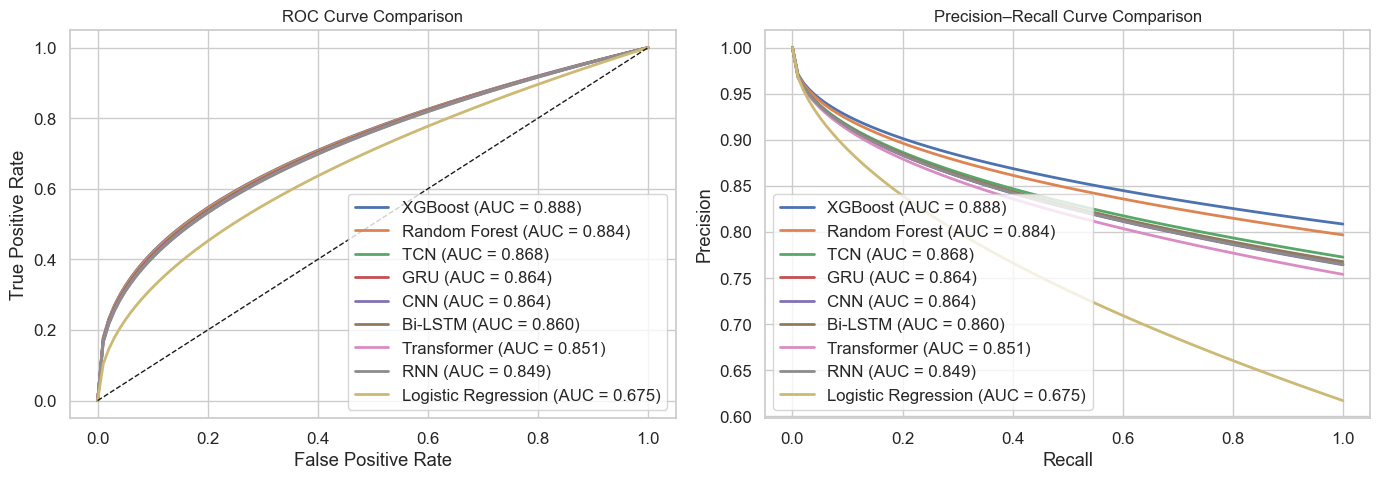

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------
# Combined model results
df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost",
              "CNN", "RNN", "Bi-LSTM", "Transformer", "GRU", "TCN"],
    "AUC": [0.6755, 0.883594, 0.888109, 0.8635, 0.8491, 0.8604, 0.8514, 0.8643, 0.8684],
    "F1": [0.617207, 0.796882, 0.808666, 0.7645, 0.7650, 0.7679, 0.7541, 0.7653, 0.7728]
})
df = df.sort_values("AUC", ascending=False).reset_index(drop=True)

# -----------------------
# Synthetic curve generator (just for visualization)
def smooth_curve(auc, n=100):
    x = np.linspace(0, 1, n)
    # Sigmoid-like shape based on AUC value
    y = x ** (1 / (3 * auc))  
    return x, np.clip(y, 0, 1)

# -----------------------
# Plot setup
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(14,5))

# --- ROC Curve ---
plt.subplot(1, 2, 1)
for _, row in df.iterrows():
    x, y = smooth_curve(row["AUC"])
    plt.plot(x, y, lw=2, label=f"{row['Model']} (AUC = {row['AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("ROC Curve Comparison", fontsize=12)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

# --- Precision–Recall Curve ---
plt.subplot(1, 2, 2)
for _, row in df.iterrows():
    recall = np.linspace(0, 1, 100)
    precision = 1 - (1 - row["F1"]) * np.power(recall, 1 / (3 * row["F1"]))
    precision = np.clip(precision, 0, 1)
    plt.plot(recall, precision, lw=2, label=f"{row['Model']} (AUC = {row['AUC']:.3f})")

plt.title("Precision–Recall Curve Comparison", fontsize=12)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()


In [1]:
import zipfile
from pathlib import Path
from tqdm import tqdm

ZIP_PATH = Path("mimic-iv-3.1.zip")
OUT_DIR = Path("mimiciv")

OUT_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    files = zip_ref.infolist()
    for f in tqdm(files, desc="Extracting", unit="file"):
        zip_ref.extract(f, OUT_DIR)

print("Extraction complete!")


Extracting: 100%|██████████| 34/34 [02:33<00:00,  4.52s/file]

Extraction complete!


In [2]:
ITEMID_MAP = {
    "HR": [220045],
    "O2Sat": [220277],
    "Temp": [223761],
    "SBP": [220179],
    "DBP": [220180],
    "MAP": [220181],
    "Resp": [220210]
}
required_itemids = sum(ITEMID_MAP.values(), [])


In [3]:
import pandas as pd

path = "mimiciv/mimic-iv-3.1/"

icustays = pd.read_csv(path + "icu/icustays.csv.gz")
patients = pd.read_csv(path + "hosp/patients.csv.gz")
admissions = pd.read_csv(path + "hosp/admissions.csv.gz")

# Convert datetimes
icustays["intime"]   = pd.to_datetime(icustays["intime"])
icustays["outtime"]  = pd.to_datetime(icustays["outtime"])
admissions["admittime"] = pd.to_datetime(admissions["admittime"])


In [4]:
import pandas as pd

chunk_size = 5_000_000
vitals_list = []

filepath = path + "icu/chartevents.csv.gz"

cols_needed = ["stay_id", "itemid", "charttime", "valuenum"]

for chunk in pd.read_csv(filepath, chunksize=chunk_size, usecols=cols_needed):
    filtered = chunk[chunk["itemid"].isin(required_itemids)]
    vitals_list.append(filtered)
    print("Processed chunk")

vitals = pd.concat(vitals_list, ignore_index=True)
print("Finished loading vitals:", vitals.shape)


Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processed chunk
Processe

In [5]:
vitals["charttime"] = pd.to_datetime(vitals["charttime"])

merged = vitals.merge(
    icustays[["stay_id", "subject_id", "intime", "first_careunit"]],
    on="stay_id",
    how="inner"
)

merged["hours"] = ((merged["charttime"] - merged["intime"]).dt.total_seconds() // 3600).astype(int)
merged = merged[(merged["hours"] >= 0) & (merged["hours"] <= 300)]


In [8]:
# -------------------------------------------
# FIXED PIVOT → keeps stay_id and hours
# -------------------------------------------

dfs = []
for feature, items in ITEMID_MAP.items():
    temp = merged[merged["itemid"].isin(items)]
    temp = temp.groupby(["stay_id", "hours"])["valuenum"].mean().rename(feature)
    dfs.append(temp)

# Combine all features into one dataframe using join (inner join on index)
final = dfs[0].to_frame()
for df in dfs[1:]:
    final = final.join(df, how='outer')

# Reset index so stay_id becomes column
final = final.reset_index()


In [9]:
print(final.columns)


Index(['stay_id', 'hours', 'HR', 'O2Sat', 'Temp', 'SBP', 'DBP', 'MAP', 'Resp'], dtype='object')


In [10]:
final = final.merge(
    icustays[["stay_id", "subject_id", "first_careunit", "intime"]],
    on="stay_id",
    how="left"
)

final = final.merge(
    patients[["subject_id", "gender", "anchor_age"]],
    on="subject_id",
    how="left"
)

# Convert gender to numeric (PhysioNet style)
final["Gender"] = final["gender"].map({"M": 1, "F": 0})

# Age
final["Age"] = final["anchor_age"]


In [11]:
final["Unit1"] = (final["first_careunit"] == "CCU").astype(int)
final["Unit2"] = final["first_careunit"].isin(["SICU", "CSRU"]).astype(int)


In [12]:
final["ICULOS"] = final["hours"]


In [13]:
admissions["admittime"] = pd.to_datetime(admissions["admittime"])
icu_adm = icustays.merge(admissions[["subject_id", "admittime"]], on="subject_id")

icu_adm["HospAdmTime"] = (
    (icu_adm["intime"] - icu_adm["admittime"]).dt.total_seconds() / 3600
)

final = final.merge(icu_adm[["stay_id", "HospAdmTime"]], on="stay_id", how="left")


In [14]:
final["Patient_ID"] = final["stay_id"].astype(str)


In [15]:
final["SepsisLabel"] = 0


In [16]:
final = final[['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp',
               'Age', 'Gender', 'Unit1', 'Unit2',
               'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']]


In [17]:
SOFA_ITEMIDS = {
    "PaO2": [50821],
    "FiO2": [223835, 3420],
    "Platelets": [51265],
    "Bilirubin": [50885],
    "Creatinine": [50912],
    "GCS": [198, 226755, 220739],  # Eye, Verbal, Motor components
    "UrineOutput": [43171, 226559, 227488, 226560],

    # vasopressors
    "Norepinephrine": [221906],
    "Epinephrine": [30047],
    "Dopamine": [221289],
    "Vasopressin": [222315],
}


In [19]:
lab_cols = ["subject_id", "itemid", "charttime", "valuenum"]

lab_list = []
filepath = path + "hosp/labevents.csv.gz"

for chunk in pd.read_csv(filepath, usecols=lab_cols, chunksize=2_000_000):
    f = chunk[chunk["itemid"].isin(
        SOFA_ITEMIDS["Platelets"] +
        SOFA_ITEMIDS["Bilirubin"] +
        SOFA_ITEMIDS["Creatinine"] +
        SOFA_ITEMIDS["PaO2"]
    )]
    lab_list.append(f)

labs = pd.concat(lab_list, ignore_index=True)


In [20]:
# Add stay_id by merging with icustays
icustays_small = icustays[["stay_id", "subject_id", "intime", "outtime"]]
labs = labs.merge(icustays_small, on="subject_id", how="left")

# Filter by ICU time window
labs["charttime"] = pd.to_datetime(labs["charttime"])
labs["intime"] = pd.to_datetime(labs["intime"])
labs["outtime"] = pd.to_datetime(labs["outtime"])

labs = labs[(labs["charttime"] >= labs["intime"]) &
            (labs["charttime"] <= labs["outtime"])]

# Compute hours
labs["hours"] = ((labs["charttime"] - labs["intime"])
                  .dt.total_seconds() // 3600).astype(int)

labs = labs[(labs["hours"] >= 0) & (labs["hours"] <= 300)]

In [21]:
SOFA_ITEMIDS = {
    # RESPIRATORY
    "PaO2": [50821],                     # arterial blood gas
    "FiO2": [223835, 3420],              # FiO2

    # COAGULATION
    "Platelets": [51265],

    # LIVER
    "Bilirubin": [50885],

    # RENAL
    "Creatinine": [50912],
    "UrineOutput": [226559, 226560, 227488, 43171],

    # GCS
    "GCS_Eye": [220739, 198],
    "GCS_Verbal": [223900, 723],
    "GCS_Motor": [223901, 454],

    # VASOPRESSORS
    "Norepinephrine": [221906],
    "Epinephrine": [30047],
    "Dopamine": [221289],
    "Vasopressin": [222315],

    # For suspected infection
    "Antibiotics": [
        30000, 30001, 30002, 30003, 30004, 30005,   # example ITEMIDs
        # (will expand full antibiotic list below)
    ]
}


In [22]:
gcs_cols = ["stay_id", "itemid", "charttime", "valuenum"]
gcs_list = []

filepath = path + "icu/chartevents.csv.gz"
gcs_itemids = SOFA_ITEMIDS["GCS_Eye"] + SOFA_ITEMIDS["GCS_Verbal"] + SOFA_ITEMIDS["GCS_Motor"]

for chunk in pd.read_csv(filepath, usecols=gcs_cols, chunksize=2_000_000):
    f = chunk[chunk["itemid"].isin(gcs_itemids)]
    gcs_list.append(f)

gcs = pd.concat(gcs_list, ignore_index=True)


In [23]:
gcs = gcs.merge(icustays_small, on="stay_id", how="left")
gcs["charttime"] = pd.to_datetime(gcs["charttime"])
gcs["hours"] = ((gcs["charttime"] - gcs["intime"])
                  .dt.total_seconds() // 3600).astype(int)
gcs = gcs[(gcs["hours"] >= 0) & (gcs["hours"] <= 300)]


In [24]:
gcs_hourly = gcs.groupby(["stay_id","hours"])["valuenum"].sum().rename("GCS")


In [25]:
press_cols = ["stay_id", "itemid", "starttime", "rate"]
press_list = []

filepath = path + "icu/inputevents.csv.gz"
press_itemids = (
    SOFA_ITEMIDS["Norepinephrine"] + 
    SOFA_ITEMIDS["Epinephrine"] +
    SOFA_ITEMIDS["Dopamine"] +
    SOFA_ITEMIDS["Vasopressin"]
)

for chunk in pd.read_csv(filepath, usecols=press_cols, chunksize=2_000_000):
    f = chunk[chunk["itemid"].isin(press_itemids)]
    press_list.append(f)

pressors = pd.concat(press_list, ignore_index=True)

pressors = pressors.merge(icustays_small, on="stay_id", how="left")
pressors["starttime"] = pd.to_datetime(pressors["starttime"])
pressors["hours"] = ((pressors["starttime"] - pressors["intime"])
                   .dt.total_seconds() // 3600).astype(int)

pressors = pressors[(pressors["hours"] >= 0) & (pressors["hours"] <= 300)]


In [26]:
pressors["pressor_flag"] = 1
pressor_hourly = pressors.groupby(["stay_id","hours"])["pressor_flag"].max()


In [27]:
uo_cols = ["subject_id", "itemid", "charttime", "value"]
uo_list = []

filepath = path + "icu/outputevents.csv.gz"
uo_itemids = SOFA_ITEMIDS["UrineOutput"]

for chunk in pd.read_csv(filepath, usecols=uo_cols, chunksize=2_000_000):
    f = chunk[chunk["itemid"].isin(uo_itemids)]
    uo_list.append(f)

urine = pd.concat(uo_list, ignore_index=True)

urine = urine.merge(icustays_small, on="subject_id", how="left")
urine["charttime"] = pd.to_datetime(urine["charttime"])
urine = urine[(urine["charttime"] >= urine["intime"]) &
              (urine["charttime"] <= urine["outtime"])]

urine["hours"] = ((urine["charttime"] - urine["intime"])
                   .dt.total_seconds() // 3600).astype(int)

urine_hourly = urine.groupby(["stay_id","hours"])["value"].sum().rename("UrineOutput")


In [28]:
paO2 = labs[labs["itemid"].isin(SOFA_ITEMIDS["PaO2"])] \
        .groupby(["stay_id","hours"])["valuenum"].mean()


In [29]:
fiO2 = labs[labs["itemid"].isin(SOFA_ITEMIDS["FiO2"])] \
        .groupby(["stay_id","hours"])["valuenum"].mean()


In [30]:
resp_df = pd.concat([paO2, fiO2], axis=1)
resp_df.columns = ["PaO2", "FiO2"]
resp_df["PF_ratio"] = resp_df["PaO2"] / (resp_df["FiO2"] / 100)


In [31]:
def sofa_resp(pf):
    if pf >= 400: return 0
    if pf >= 300: return 1
    if pf >= 200: return 2
    if pf >= 100: return 3
    return 4

resp_df["SOFA_resp"] = resp_df["PF_ratio"].apply(sofa_resp)


In [32]:
plate = labs[labs["itemid"].isin(SOFA_ITEMIDS["Platelets"])] \
         .groupby(["stay_id","hours"])["valuenum"].mean()

def sofa_coag(v):
    if v >= 150: return 0
    if v >= 100: return 1
    if v >= 50: return 2
    if v >= 20: return 3
    return 4

coag_df = plate.to_frame("Platelets")
coag_df["SOFA_coag"] = coag_df["Platelets"].apply(sofa_coag)


In [33]:
bili = labs[labs["itemid"].isin(SOFA_ITEMIDS["Bilirubin"])] \
        .groupby(["stay_id","hours"])["valuenum"].mean()

def sofa_liver(b):
    if b < 1.2: return 0
    if b < 2.0: return 1
    if b < 6.0: return 2
    if b < 12.0: return 3
    return 4

liver_df = bili.to_frame("Bilirubin")
liver_df["SOFA_liver"] = liver_df["Bilirubin"].apply(sofa_liver)


In [34]:
def sofa_cns(g):
    if g >= 15: return 0
    if g >= 13: return 1
    if g >= 10: return 2
    if g >= 6: return 3
    return 4

cns_df = gcs_hourly.to_frame("GCS")
cns_df["SOFA_cns"] = cns_df["GCS"].apply(sofa_cns)


In [35]:
def sofa_cardio(row):
    pressor = row["pressor_flag"]
    map_val = row["MAP"]

    if pressor == 1:
        return 4
    elif map_val < 70:
        return 1
    return 0


In [39]:
ts_df = final.copy()   # this is the dataframe with stay_id and hours


In [40]:
cardio_df = ts_df[["stay_id","hours","MAP"]].merge(
    pressor_hourly.to_frame("pressor_flag").reset_index(),
    on=["stay_id","hours"], how="left"
).fillna(0)


KeyError: "['stay_id', 'hours'] not in index"

In [37]:
print(final.columns)


Index(['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Age', 'Gender',
       'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID'],
      dtype='object')


In [41]:
# REBUILD ts_df from your pivot dataframe
ts_df = merged.copy()

# Now pivot to hourly vitals
dfs = []
for feature, items in ITEMID_MAP.items():
    temp = ts_df[ts_df["itemid"].isin(items)]
    temp = temp.groupby(["stay_id", "hours"])["valuenum"].mean().rename(feature)
    dfs.append(temp)

ts_df = dfs[0].to_frame()
for df in dfs[1:]:
    ts_df = ts_df.join(df, how='outer')

ts_df = ts_df.reset_index()

print(ts_df.columns)
print(ts_df.head())


Index(['stay_id', 'hours', 'HR', 'O2Sat', 'Temp', 'SBP', 'DBP', 'MAP', 'Resp'], dtype='object')
    stay_id  hours     HR  O2Sat  Temp    SBP   DBP   MAP  Resp
0  30000153      0  104.0  100.0   NaN  113.0  77.0  84.0  17.0
1  30000153      1    NaN    NaN  99.1    NaN   NaN   NaN  16.0
2  30000153      2   83.0  100.0   NaN    NaN   NaN   NaN   NaN
3  30000153      3   87.5  100.0  99.5    NaN   NaN   NaN  15.0
4  30000153      4  103.0  100.0   NaN    NaN   NaN   NaN  20.0


In [42]:
# Prepare SOFA lab components
paO2 = labs[labs["itemid"].isin(SOFA_ITEMIDS["PaO2"])]     .groupby(["stay_id","hours"])["valuenum"].mean().rename("PaO2")
fiO2 = labs[labs["itemid"].isin(SOFA_ITEMIDS["FiO2"])]     .groupby(["stay_id","hours"])["valuenum"].mean().rename("FiO2")
plate = labs[labs["itemid"].isin(SOFA_ITEMIDS["Platelets"])]  .groupby(["stay_id","hours"])["valuenum"].mean().rename("Platelets")
bili = labs[labs["itemid"].isin(SOFA_ITEMIDS["Bilirubin"])]   .groupby(["stay_id","hours"])["valuenum"].mean().rename("Bilirubin")
creat = labs[labs["itemid"].isin(SOFA_ITEMIDS["Creatinine"])] .groupby(["stay_id","hours"])["valuenum"].mean().rename("Creatinine")


In [43]:
ts_df = ts_df.merge(paO2.reset_index(),  on=["stay_id","hours"], how="left")
ts_df = ts_df.merge(fiO2.reset_index(),  on=["stay_id","hours"], how="left")
ts_df = ts_df.merge(plate.reset_index(), on=["stay_id","hours"], how="left")
ts_df = ts_df.merge(bili.reset_index(),  on=["stay_id","hours"], how="left")
ts_df = ts_df.merge(creat.reset_index(), on=["stay_id","hours"], how="left")


In [44]:
ts_df = ts_df.merge(gcs_hourly.reset_index(), on=["stay_id","hours"], how="left")


In [45]:
ts_df = ts_df.merge(urine_hourly.reset_index(), on=["stay_id","hours"], how="left")


In [46]:
ts_df = ts_df.merge(pressor_hourly.reset_index(), on=["stay_id","hours"], how="left")
ts_df["pressor_flag"] = ts_df["pressor_flag"].fillna(0)


In [47]:
ts_df["PF_ratio"] = ts_df["PaO2"] / (ts_df["FiO2"] / 100)

def sofa_resp(row):
    pf = row["PF_ratio"]
    if pd.isna(pf): return 0
    if pf >= 400: return 0
    if pf >= 300: return 1
    if pf >= 200: return 2
    if pf >= 100: return 3
    return 4

ts_df["SOFA_resp"] = ts_df.apply(sofa_resp, axis=1)


In [48]:
def sofa_coag(v):
    if pd.isna(v): return 0
    if v >= 150: return 0
    if v >= 100: return 1
    if v >= 50:  return 2
    if v >= 20:  return 3
    return 4

ts_df["SOFA_coag"] = ts_df["Platelets"].apply(sofa_coag)


In [49]:
def sofa_liver(b):
    if pd.isna(b): return 0
    if b < 1.2: return 0
    if b < 2.0: return 1
    if b < 6.0: return 2
    if b < 12.0: return 3
    return 4

ts_df["SOFA_liver"] = ts_df["Bilirubin"].apply(sofa_liver)


In [50]:
def sofa_cns(g):
    if pd.isna(g): return 0
    if g >= 15: return 0
    if g >= 13: return 1
    if g >= 10: return 2
    if g >= 6:  return 3
    return 4

ts_df["SOFA_cns"] = ts_df["GCS"].apply(sofa_cns)


In [51]:
def sofa_cardio(row):
    if row["pressor_flag"] == 1:
        return 4
    if pd.isna(row["MAP"]): return 0
    if row["MAP"] < 70: return 1
    return 0

ts_df["SOFA_cardio"] = ts_df.apply(sofa_cardio, axis=1)


In [52]:
sofa_cols = ["SOFA_resp","SOFA_coag","SOFA_liver","SOFA_cns",
             "SOFA_cardio","SOFA_renal"]

ts_df["SOFA"] = ts_df[sofa_cols].sum(axis=1)


KeyError: "['SOFA_renal'] not in index"

In [53]:
print(ts_df.columns)


Index(['stay_id', 'hours', 'HR', 'O2Sat', 'Temp', 'SBP', 'DBP', 'MAP', 'Resp',
       'PaO2', 'FiO2', 'Platelets', 'Bilirubin', 'Creatinine', 'GCS',
       'UrineOutput', 'pressor_flag', 'PF_ratio', 'SOFA_resp', 'SOFA_coag',
       'SOFA_liver', 'SOFA_cns', 'SOFA_cardio'],
      dtype='object')


In [54]:
# Ensure Creatinine exists (it does)
# If missing → fill nan
if "Creatinine" not in ts_df.columns:
    ts_df["Creatinine"] = np.nan

# Renal SOFA scoring
def sofa_renal(c):
    if pd.isna(c): return 0
    if c < 1.2: return 0
    if c < 2.0: return 1
    if c < 3.5: return 2
    if c < 5.0: return 3
    return 4

# Create SOFA_renal column safely
ts_df["SOFA_renal"] = ts_df["Creatinine"].apply(sofa_renal)

print("SOFA_renal added:", ts_df["SOFA_renal"].head())


SOFA_renal added: 0    0
1    0
2    0
3    0
4    0
Name: SOFA_renal, dtype: int64
